# Autoencoder (AE)



## AE

* Implementing a basic Autoencoder model and training loop that has a bottleneck, i.e., smaller latent dimension size as input/out dimension size.
* Training the Autoencoder on the MNIST dataset.
* Visualizing some original and reconstructed images from the test set.
* Visualizing the embeddings ofa subset (10 samples) of the test samples using `t-SNE`. We will be using our trained encoder model to create those embeddings.

Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 58.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.78MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.20MB/s]


Training Autoencoder...
Epoch [1/10], Loss: 0.0518
Epoch [2/10], Loss: 0.0245
Epoch [3/10], Loss: 0.0196
Epoch [4/10], Loss: 0.0173
Epoch [5/10], Loss: 0.0161
Epoch [6/10], Loss: 0.0153
Epoch [7/10], Loss: 0.0148
Epoch [8/10], Loss: 0.0143
Epoch [9/10], Loss: 0.0138
Epoch [10/10], Loss: 0.0134
Training completed!
Test Loss: 0.0129

Visualizing reconstructions...


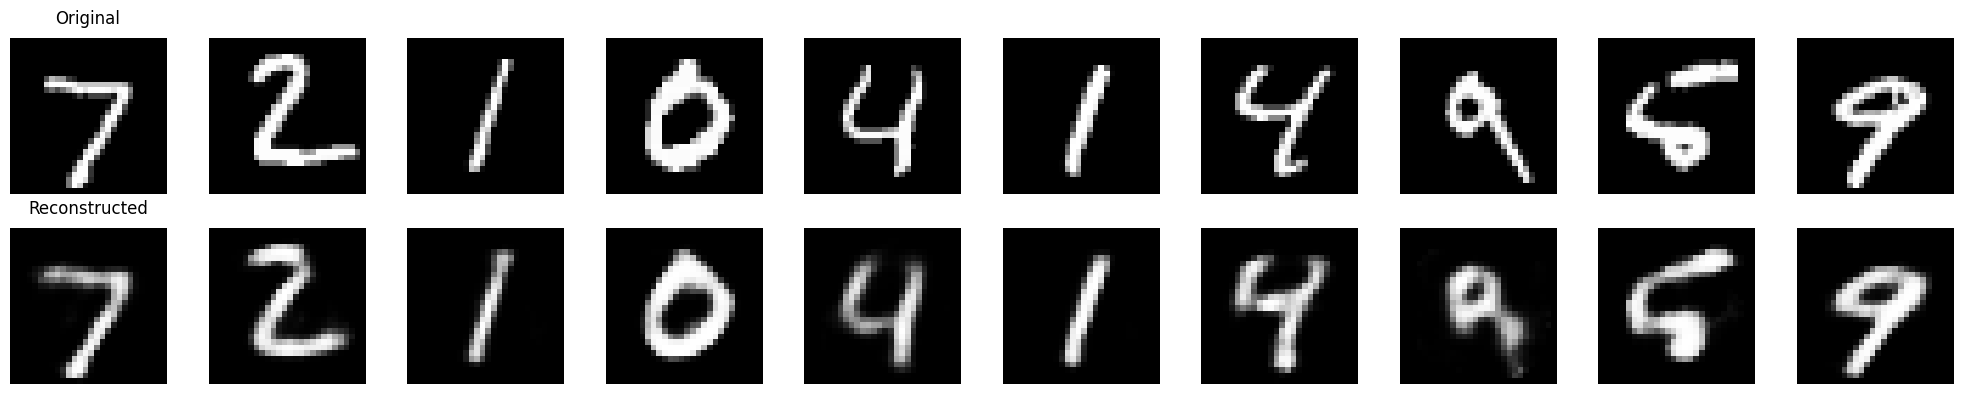


Visualizing embeddings with t-SNE...


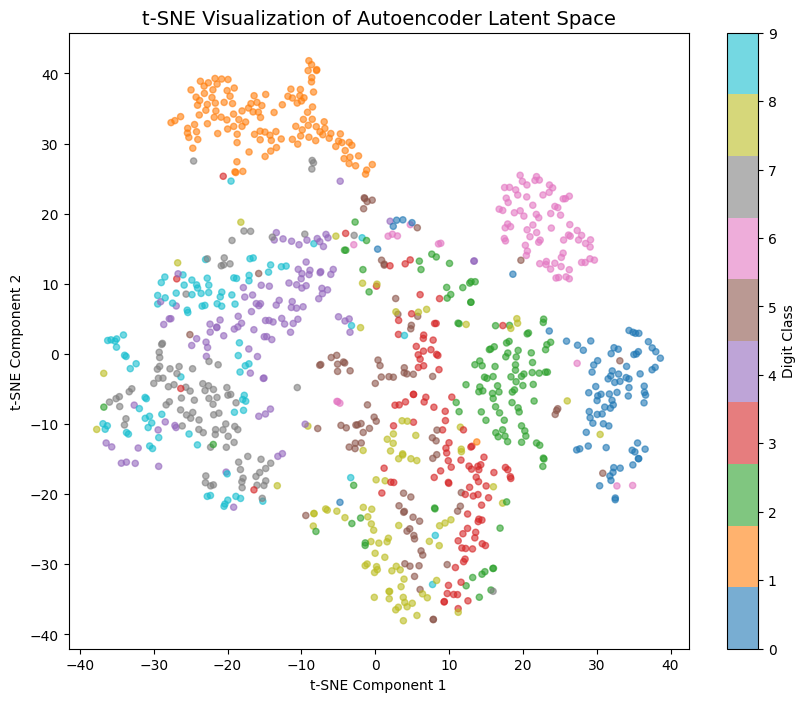


Autoencoder task completed!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
input_dim = 784  # 28x28 images flattened
latent_dim = 32  # Bottleneck dimension (smaller than input)
hidden_dim = 128
batch_size = 128
learning_rate = 1e-3
num_epochs = 10

# Data preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define Autoencoder model
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # Output in [0, 1] range
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def encode(self, x):
        return self.encoder(x)

# Initialize model
model = Autoencoder(input_dim, hidden_dim, latent_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
print("Training Autoencoder...")
train_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        # Flatten images
        data = data.view(-1, input_dim).to(device)

        # Forward pass
        reconstructed = model(data)
        loss = criterion(reconstructed, data)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

print("Training completed!")

# Evaluate on test set
model.eval()
test_loss = 0
with torch.no_grad():
    for data, _ in test_loader:
        data = data.view(-1, input_dim).to(device)
        reconstructed = model(data)
        test_loss += criterion(reconstructed, data).item()

print(f'Test Loss: {test_loss / len(test_loader):.4f}')

# Visualize original and reconstructed images
print("\nVisualizing reconstructions...")
model.eval()
with torch.no_grad():
    # Get a batch of test images
    test_images, _ = next(iter(test_loader))
    test_images_flat = test_images.view(-1, input_dim).to(device)
    reconstructed = model(test_images_flat)

    # Move to CPU for visualization
    test_images = test_images.cpu().numpy()
    reconstructed = reconstructed.view(-1, 28, 28).cpu().numpy()

    # Plot 10 original and reconstructed images
    n = 10
    fig, axes = plt.subplots(2, n, figsize=(20, 4))

    for i in range(n):
        # Original images
        axes[0, i].imshow(test_images[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=12, pad=10)

        # Reconstructed images
        axes[1, i].imshow(reconstructed[i], cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Reconstructed', fontsize=12, pad=10)

    plt.tight_layout()
    plt.savefig('autoencoder_reconstructions.png', dpi=150, bbox_inches='tight')
    plt.show()

# Visualize embeddings using t-SNE
print("\nVisualizing embeddings with t-SNE...")
model.eval()
with torch.no_grad():
    # Get more samples for better t-SNE visualization (1000 samples, 100 per digit)
    embeddings_list = []
    labels_list = []

    for data, labels in test_loader:
        data = data.view(-1, input_dim).to(device)
        embeddings = model.encode(data)
        embeddings_list.append(embeddings.cpu().numpy())
        labels_list.append(labels.numpy())

        # Stop after collecting enough samples
        if len(embeddings_list) * batch_size >= 1000:
            break

    # Concatenate all embeddings and labels
    embeddings_array = np.concatenate(embeddings_list, axis=0)[:1000]
    labels_array = np.concatenate(labels_list, axis=0)[:1000]

    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d = tsne.fit_transform(embeddings_array)

    # Plot t-SNE visualization
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                         c=labels_array, cmap='tab10', alpha=0.6, s=20)
    plt.colorbar(scatter, label='Digit Class')
    plt.title('t-SNE Visualization of Autoencoder Latent Space', fontsize=14)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.savefig('autoencoder_tsne.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\nAutoencoder task completed!")


## VAE: Variational Autoencoder Model

* Implementing a Variational Autoencoder model and training loop. We will be implementing it using thereparametrization trick.
* Training the Variational Autoencoder on the MNIST dataset.
* Visualizing some original and reconstructed images from the test set.
* Sample 10 synthetic images from the learned latent space by sampling from the prior distribution and passing the samples through the decoder.


Training Variational Autoencoder...
Epoch [1/15], Loss: 173.7832
Epoch [2/15], Loss: 126.6332
Epoch [3/15], Loss: 117.8967
Epoch [4/15], Loss: 114.2080
Epoch [5/15], Loss: 112.1439
Epoch [6/15], Loss: 110.7386
Epoch [7/15], Loss: 109.7663
Epoch [8/15], Loss: 108.9998
Epoch [9/15], Loss: 108.4188
Epoch [10/15], Loss: 107.9453
Epoch [11/15], Loss: 107.5448
Epoch [12/15], Loss: 107.1794
Epoch [13/15], Loss: 106.8849
Epoch [14/15], Loss: 106.5882
Epoch [15/15], Loss: 106.3602
VAE training completed!
VAE Test Loss: 105.9749

Visualizing VAE reconstructions...


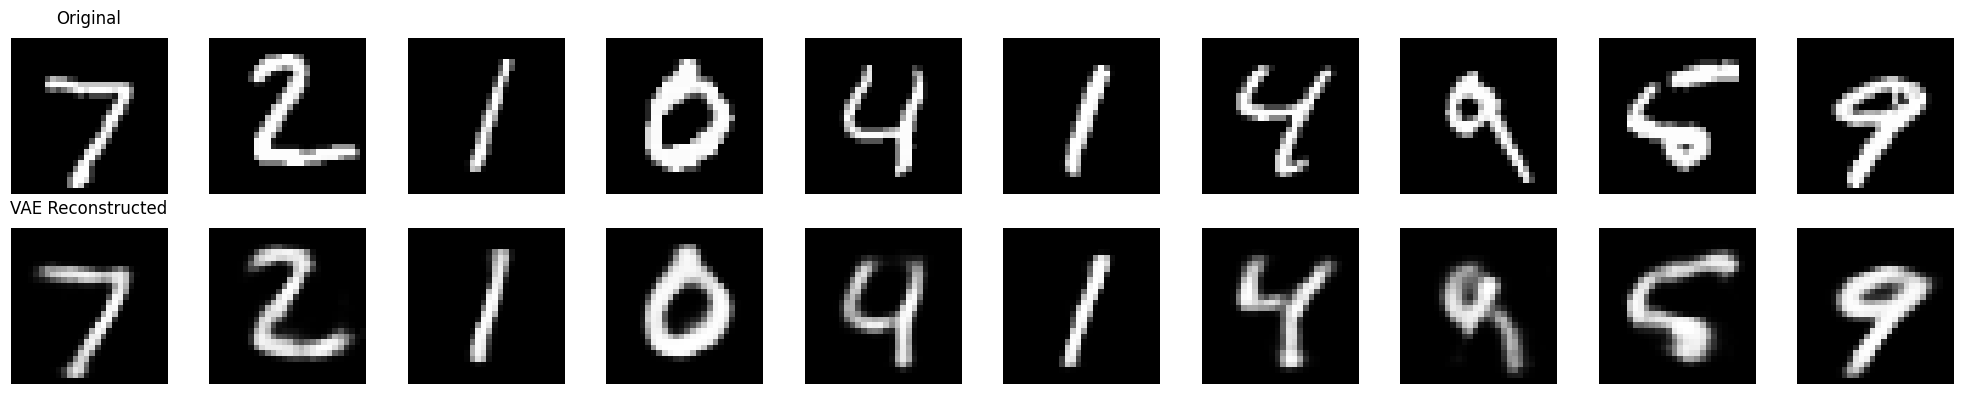


Sampling synthetic images from latent space...


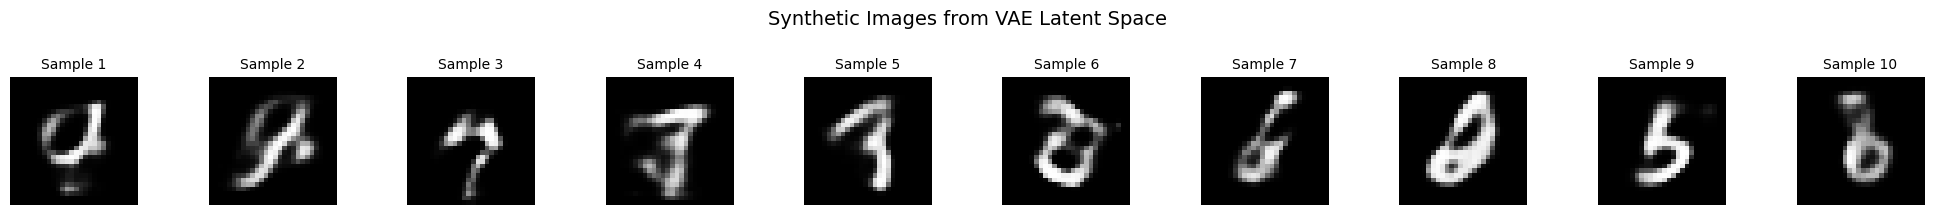


VAE task completed!


In [ ]:
# Variational Autoencoder Implementation

# Hyperparameters for VAE
vae_latent_dim = 20
vae_hidden_dim = 256
vae_num_epochs = 15

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """Reparameterization trick: z = mu + sigma * epsilon"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(reconstructed, original, mu, logvar):
    """VAE loss = Reconstruction loss + KL divergence"""
    # Reconstruction loss (Binary Cross Entropy)
    BCE = nn.functional.binary_cross_entropy(reconstructed, original, reduction='sum')

    # KL divergence: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD

# Initialize VAE
vae_model = VAE(input_dim, vae_hidden_dim, vae_latent_dim).to(device)
vae_optimizer = optim.Adam(vae_model.parameters(), lr=learning_rate)

# Training loop for VAE
print("\nTraining Variational Autoencoder...")
vae_train_losses = []

for epoch in range(vae_num_epochs):
    vae_model.train()
    total_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.view(-1, input_dim).to(device)

        # Forward pass
        reconstructed, mu, logvar = vae_model(data)
        loss = vae_loss(reconstructed, data, mu, logvar)

        # Backward pass
        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    vae_train_losses.append(avg_loss)
    print(f'Epoch [{epoch+1}/{vae_num_epochs}], Loss: {avg_loss:.4f}')

print("VAE training completed!")

# Evaluate VAE on test set
vae_model.eval()
test_loss = 0
with torch.no_grad():
    for data, _ in test_loader:
        data = data.view(-1, input_dim).to(device)
        reconstructed, mu, logvar = vae_model(data)
        test_loss += vae_loss(reconstructed, data, mu, logvar).item()

print(f'VAE Test Loss: {test_loss / len(test_loader.dataset):.4f}')

# Visualize VAE reconstructions
print("\nVisualizing VAE reconstructions...")
vae_model.eval()
with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images_flat = test_images.view(-1, input_dim).to(device)
    reconstructed, _, _ = vae_model(test_images_flat)

    test_images = test_images.cpu().numpy()
    reconstructed = reconstructed.view(-1, 28, 28).cpu().numpy()

    # Plot 10 original and reconstructed images
    n = 10
    fig, axes = plt.subplots(2, n, figsize=(20, 4))

    for i in range(n):
        axes[0, i].imshow(test_images[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=12, pad=10)

        axes[1, i].imshow(reconstructed[i], cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('VAE Reconstructed', fontsize=12, pad=10)

    plt.tight_layout()
    plt.savefig('vae_reconstructions.png', dpi=150, bbox_inches='tight')
    plt.show()

# Sample synthetic images from the latent space
print("\nSampling synthetic images from latent space...")
vae_model.eval()
with torch.no_grad():
    # Sample from standard normal distribution (prior)
    z = torch.randn(10, vae_latent_dim).to(device)

    # Decode the samples
    synthetic_images = vae_model.decode(z)
    synthetic_images = synthetic_images.view(-1, 28, 28).cpu().numpy()

    # Plot synthetic images
    fig, axes = plt.subplots(1, 10, figsize=(20, 2))
    for i in range(10):
        axes[i].imshow(synthetic_images[i], cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f'Sample {i+1}', fontsize=10)

    plt.suptitle('Synthetic Images from VAE Latent Space', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.savefig('vae_synthetic_samples.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\nVAE task completed!")
